In [1]:
import os
import torch
import numpy as np

# Global variable to track communication cost in bytes
communication_log = []

def compute_communication_cost(tensor, data_type_size=4):
    # data_type_size=4 for float32
    if isinstance(tensor, dict):
        size = sum(param.numel() for param in tensor.values())
    else:
        size = tensor.numel()
    return size * data_type_size


In [2]:

def top_k_sparsify(tensor, k=1000):
    flat = tensor.flatten()
    if flat.numel() <= k:
        return tensor
    values, indices = torch.topk(flat.abs(), k)
    mask = torch.zeros_like(flat)
    mask[indices] = 1
    sparse_tensor = (flat * mask).reshape(tensor.shape)
    return sparse_tensor

def quantize_tensor(tensor, num_bits=8):
    qmin = 0.
    qmax = 2.**num_bits - 1.
    min_val, max_val = tensor.min(), tensor.max()
    scale = (max_val - min_val) / (qmax - qmin)
    quantized = ((tensor - min_val) / scale).round().clamp(qmin, qmax)
    return quantized


In [3]:

def log_and_update(user_model, neighbor_models, k=1000, quantize=False):
    global communication_log
    # Peer-to-peer model averaging (e.g., gossip-style)
    neighbor_avg = sum(neighbor_models) / len(neighbor_models)

    # Log outgoing communication
    for neighbor_model in neighbor_models:
        delta = user_model - neighbor_model
        sparse_delta = top_k_sparsify(delta, k)
        if quantize:
            sparse_delta = quantize_tensor(sparse_delta)
        cost = compute_communication_cost(sparse_delta)
        communication_log.append(cost)
    
    # Update user model
    user_model = 0.5 * user_model + 0.5 * neighbor_avg
    return user_model


In [4]:
import pandas as pd
import numpy as np
import networkx as nx
import gc
import os
import itertools
from itertools import product
from sklearn.model_selection import train_test_split


In [5]:
from os import chdir
from pathlib import Path

new_path = Path("/Users/haowen/Documents/Decentral RS/fed-learning-main")

if new_path.exists():
    os.chdir(new_path)
    print(f"Working directory changed to: {Path.cwd()}")
else:
    print("Path does not exist.")


Working directory changed to: /Users/haowen/Documents/Decentral RS/fed-learning-main


In [6]:
SAMPLED_DATA_DIR = r"/Users/haowen/Documents/Decentral RS/rebuttal/code/8"
SEED             = 42

train_path = os.path.join(SAMPLED_DATA_DIR, "hm_subset_train.csv")
test_path  = os.path.join(SAMPLED_DATA_DIR, "hm_subset_test.csv")

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)

# Cast IDs to str to handle mixed-type H&M IDs consistently
for df in [train_df, test_df]:
    df["user_id"] = df["user_id"].astype(str)
    df["item_id"] = df["item_id"].astype(str)

# Build contiguous 0-based encoders fitted on train only
user_enc = {u: i for i, u in enumerate(sorted(train_df["user_id"].unique()))}
item_enc = {v: i for i, v in enumerate(sorted(train_df["item_id"].unique()))}

def remap(df, user_enc, item_enc, drop_unknown=False):
    df = df.copy()
    if drop_unknown:
        df = df[df["user_id"].isin(user_enc) & df["item_id"].isin(item_enc)]
    df["user_id"] = df["user_id"].map(user_enc)
    df["item_id"] = df["item_id"].map(item_enc)
    return df.dropna(subset=["user_id", "item_id"]).astype({"user_id": int, "item_id": int})

train_df = remap(train_df, user_enc, item_enc)
test_df  = remap(test_df,  user_enc, item_enc, drop_unknown=True)

train_df, val_df = train_test_split(train_df, test_size=0.2, random_state=0)

n_users = len(user_enc)
n_items = len(item_enc)
print(f"Total Users : {n_users}")
print(f"Total Items : {n_items}")
train_df.head()


Total Users : 1760
Total Items : 2881


,user_id,item_id,bought
17812,23,2123,1
788,491,714,1
1399,357,1741,1
12060,590,1828,1
31118,1248,1025,1


In [7]:
# Data loaded and remapped above.
print(f"Train rows : {len(train_df)}")
print(f"Val rows   : {len(val_df)}")
print(f"Test rows  : {len(test_df)}")
print(f"Rating col : {train_df.columns[2]}  "
      f"range [{train_df.iloc[:,2].min()}, {train_df.iloc[:,2].max()}]")


Train rows : 62568
Val rows   : 15643
Test rows  : 19553
Rating col : bought  range [1, 24]


In [8]:
class SparseFastNeighborDMF_NX:
    def __init__(self, num_users, num_items, latent_dim=10, lr=0.01,
                 alpha=0.01, beta=0.01, gamma=0.01, top_k=10):
        self.num_users = num_users
        self.num_items = num_items
        self.latent_dim = latent_dim
        self.lr = lr
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.top_k = top_k
        self.comm_cost = {u: {'sent': 0, 'recv': 0} for u in range(self.num_users)}

        self.user_factors = np.random.normal(scale=0.1, size=(num_users, latent_dim))
        self.common_item_factors = np.random.normal(scale=0.1, size=(num_items, latent_dim))
        self.personal_item_factors = {}  # (user_id, item_id) -> latent vector
        self.neighbors = {}

        # Logs
        self.epoch_times = []
        self.gradient_sharing_counts = []

    def build_neighbors_networkx(self, graph):
        """Build neighbor lists from a pre-constructed networkx graph.
        Pass graph=None for no peer sharing."""
        # FIX: use None sentinel instead of broken np.isnan check on a graph object
        G = graph if graph is not None else nx.Graph()

        for user_id in range(self.num_users):
            neighbors = list(G.neighbors(user_id)) if user_id in G else []
            if len(neighbors) > self.top_k:
                neighbors = list(np.random.choice(neighbors, size=self.top_k, replace=False))
            self.neighbors[user_id] = neighbors

    def train(self, data, val_data=None, epochs=100, patience=5, time_threshold=60):
        import time

        self.epoch_times = []
        self.gradient_sharing_counts = []
        self.train_losses = []
        self.val_losses = []
        epoch_summary = {}

        best_val_loss = float('inf')
        no_improve_count = 0

        for epoch in range(epochs):
            start_time = time.time()
            gradient_sharing_count = 0
            mse_train = 0.0

            np.random.shuffle(data)
            for user_id, item_id, rating in data:
                u = self.user_factors[user_id]
                p = self.common_item_factors[item_id]
                q_key = (user_id, item_id)
                if q_key not in self.personal_item_factors:
                    self.personal_item_factors[q_key] = np.random.normal(
                        scale=0.1, size=self.latent_dim)
                q = self.personal_item_factors[q_key]

                pred = np.dot(u, p + q)
                error = rating - pred
                mse_train += error ** 2

                grad_u = -error * (p + q) + self.alpha * u
                grad_p = -error * u + self.beta * p
                grad_q = -error * u + self.gamma * q

                self.user_factors[user_id] -= self.lr * grad_u
                self.personal_item_factors[q_key] -= self.lr * grad_q

                # FIX: user updates their own item factor unconditionally
                self.common_item_factors[item_id] -= self.lr * grad_p

                # FIX: then sends grad_p to each neighbor so they also apply it
                for neighbor_id in self.neighbors.get(user_id, []):
                    self.common_item_factors[item_id] -= self.lr * grad_p
                    gradient_sharing_count += 1

            epoch_time = time.time() - start_time
            rmse_train = np.sqrt(mse_train / len(data))

            # Validation loss
            if val_data is not None:
                mse_val = 0.0
                for user_id, item_id, rating in val_data:
                    pred = self.predict(user_id, item_id)
                    mse_val += (rating - pred) ** 2
                rmse_val = np.sqrt(mse_val / len(val_data))
            else:
                rmse_val = None

            # Store logs
            self.epoch_times.append(epoch_time)
            self.gradient_sharing_counts.append(gradient_sharing_count)
            self.train_losses.append(rmse_train)
            self.val_losses.append(rmse_val)
            epoch_summary[epoch] = {
                'time': epoch_time,
                'gradient_sharing': gradient_sharing_count,
                'train_rmse': rmse_train,
                'val_rmse': rmse_val
            }

            # Early stopping
            if rmse_val is not None:
                if rmse_val < best_val_loss:
                    best_val_loss = rmse_val
                    no_improve_count = 0
                else:
                    no_improve_count += 1

                if no_improve_count >= patience:
                    print(f"Early stopping: No improvement in validation loss for {patience} epochs.")
                    break

            if epoch_time > time_threshold:
                print(f"Early stopping: Epoch time exceeded {time_threshold} seconds.")
                break

        return epoch_summary

    def predict(self, user_id, item_id):
        u = self.user_factors[user_id]
        p = self.common_item_factors[item_id]
        q_key = (user_id, item_id)
        q = self.personal_item_factors.get(q_key, np.zeros(self.latent_dim))
        return np.dot(u, p + q)

    def compute_rmse(self, data):
        mse = 0.0
        for user_id, item_id, rating in data:
            pred = self.predict(user_id, item_id)
            mse += (rating - pred) ** 2
        return np.sqrt(mse / len(data))


In [9]:
# ── Build interaction tuples ──────────────────────────────────────────────────
# Treat first three columns as (user_id, item_id, rating) regardless of names.
def to_tuples(df):
    return list(df.iloc[:, :3].itertuples(index=False, name=None))

train_tuples = to_tuples(train_df)
val_tuples   = to_tuples(val_df)
test_tuples  = to_tuples(test_df)

print(f"Train: {len(train_tuples)} interactions")
print(f"Val  : {len(val_tuples)} interactions")
print(f"Test : {len(test_tuples)} interactions")

# ── Communication graph (random-2-out via networkx) ───────────────────────────
# Each node u picks 2 random out-neighbours; result is a directed graph.
np.random.seed(SEED)
G = nx.DiGraph()
G.add_nodes_from(range(n_users))
for u in range(n_users):
    candidates = [v for v in range(n_users) if v != u]
    targets    = np.random.choice(candidates, size=2, replace=False)
    for t in targets:
        G.add_edge(u, t)
graph = G.to_undirected()
print(f"Graph built: random_2_out, {n_users} nodes, {graph.number_of_edges()} edges")


Train: 62568 interactions
Val  : 15643 interactions
Test : 19553 interactions
Graph built: random_2_out, 1760 nodes, 3518 edges


In [10]:
# ── Grid search ───────────────────────────────────────────────────────────────
LATENT_GRID = [8,     16,    32  ]
LR_GRID     = [0.001, 0.005, 0.01]
TOP_K_GRID  = [5,     10,    15  ]
TUNE_EPOCHS = 30
TUNE_PAT    = 5
TUNE_TIME   = 30    # per-epoch time threshold (seconds)

param_grid = list(product(LATENT_GRID, LR_GRID, TOP_K_GRID))
print(f"Grid search: {len(param_grid)} combinations x up to {TUNE_EPOCHS} epochs")
print(f"{'#':>3}  {'dim':>5}  {'lr':>7}  {'top_k':>6}  {'best val RMSE':>14}")
print("-" * 44)

best_rmse   = float("inf")
best_config = None
gs_results  = []

for _k, (dim, lr, k) in enumerate(param_grid, 1):
    _model = SparseFastNeighborDMF_NX(
        num_users=n_users, num_items=n_items,
        latent_dim=dim, lr=lr, top_k=k
    )
    _model.build_neighbors_networkx(graph)
    _model.train(train_tuples, val_data=val_tuples,
                 epochs=TUNE_EPOCHS, patience=TUNE_PAT,
                 time_threshold=TUNE_TIME)

    val_rmse = _model.compute_rmse(val_tuples)
    gs_results.append((dim, lr, k, val_rmse))

    if val_rmse < best_rmse:
        best_rmse   = val_rmse
        best_config = (dim, lr, k)

    _marker = ' <--' if val_rmse == best_rmse else ''
    print(f"{_k:>3}  {dim:>5d}  {lr:>7.4f}  {k:>6d}  {val_rmse:>14.4f}{_marker}")

    del _model
    gc.collect()

print(f"\nBest val RMSE  : {best_rmse:.4f}")
print(f"  latent_dim     = {best_config[0]}")
print(f"  lr             = {best_config[1]}")
print(f"  top_k          = {best_config[2]}")


Grid search: 27 combinations x up to 30 epochs
  #    dim       lr   top_k   best val RMSE
--------------------------------------------
  1      8   0.0010       5          1.4328 <--
  2      8   0.0010      10          1.3678 <--
  3      8   0.0010      15          1.4552
Early stopping: No improvement in validation loss for 5 epochs.
  4      8   0.0050       5          1.0564 <--
Early stopping: No improvement in validation loss for 5 epochs.
  5      8   0.0050      10          1.0644
Early stopping: No improvement in validation loss for 5 epochs.
  6      8   0.0050      15          1.0507 <--
Early stopping: No improvement in validation loss for 5 epochs.
  7      8   0.0100       5          1.0655
Early stopping: No improvement in validation loss for 5 epochs.
  8      8   0.0100      10          1.0791
Early stopping: No improvement in validation loss for 5 epochs.
  9      8   0.0100      15          1.0687
 10     16   0.0010       5          1.4471
 11     16   0.0010     

In [11]:
# ── Retrain best config, evaluate on test ────────────────────────────────────
best_model = SparseFastNeighborDMF_NX(
    num_users=n_users,
    num_items=n_items,
    latent_dim=best_config[0],
    lr=best_config[1],
    top_k=best_config[2]
)
best_model.build_neighbors_networkx(graph)
best_model.train(train_tuples, val_data=val_tuples, epochs=50, patience=5)

test_rmse = best_model.compute_rmse(test_tuples)
print(f"Test RMSE: {test_rmse:.4f}")


Early stopping: No improvement in validation loss for 5 epochs.
Test RMSE: 1.0354


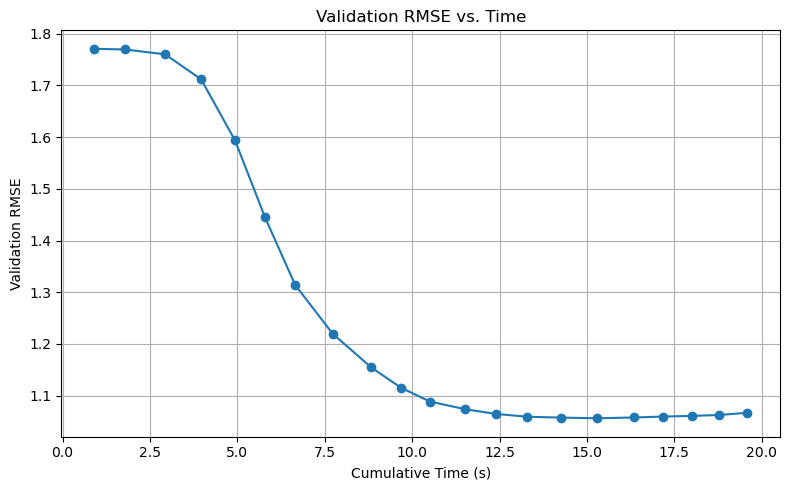

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Compute cumulative time
cumulative_time = np.cumsum(best_model.epoch_times)

# Plot validation RMSE vs. cumulative training time
plt.figure(figsize=(8, 5))
plt.plot(cumulative_time, best_model.val_losses, marker='o')
plt.xlabel("Cumulative Time (s)")
plt.ylabel("Validation RMSE")
plt.title("Validation RMSE vs. Time")
plt.grid(True)
plt.tight_layout()
plt.show()

In [13]:
best_model.epoch_times

[0.8978009223937988,
 0.8804419040679932,
 1.1513378620147705,
 1.0314288139343262,
 0.9693560600280762,
 0.8589839935302734,
 0.8631069660186768,
 1.0727972984313965,
 1.100862979888916,
 0.8487889766693115,
 0.8323647975921631,
 1.016746997833252,
 0.8608169555664062,
 0.9010663032531738,
 0.9704902172088623,
 1.0374820232391357,
 1.0401840209960938,
 0.8508448600769043,
 0.8052060604095459,
 0.7870111465454102,
 0.809967041015625]

In [14]:
best_model.gradient_sharing_counts 

[249072,
 249072,
 249072,
 249072,
 249072,
 249072,
 249072,
 249072,
 249072,
 249072,
 249072,
 249072,
 249072,
 249072,
 249072,
 249072,
 249072,
 249072,
 249072,
 249072,
 249072]

In [15]:
best_model.val_losses

[1.7707794770857699,
 1.7694959744848195,
 1.7601067091422047,
 1.7117767390933485,
 1.5936197668950436,
 1.4447251676771782,
 1.3138303551831914,
 1.219646677652302,
 1.154585104323629,
 1.115417861118197,
 1.088463178897414,
 1.0735743982164339,
 1.0646387423310686,
 1.0591788807064186,
 1.0574439981970778,
 1.0562157519728808,
 1.0576816644932128,
 1.059531444794013,
 1.0607191833510465,
 1.0625546111222877,
 1.0667753380420502]

In [16]:
log ={}
log["rmse"] = best_model.val_losses
log["cost"] = best_model.gradient_sharing_counts 
log["time"] = best_model.epoch_times

In [17]:
# FIX: pd.DataFrame(log) produces 50-row x 3-col table
# (from_dict orient='index' produced an inverted 3-row x 50-col table)
df = pd.DataFrame(log)          # columns: rmse, cost, time; one row per epoch
df.index.name = "epoch"
df.reset_index(inplace=True)
df.to_csv("dmf_hm.csv", index=False)
df.head()


,epoch,rmse,cost,time
0,0,1.770779,249072,0.897801
1,1,1.769496,249072,0.880442
2,2,1.760107,249072,1.151338
3,3,1.711777,249072,1.031429
4,4,1.593620,249072,0.969356
